# SF8xxx Controller Validation Notebook

In [1]:
import time
from pymeasure.instruments.maiman_laser_controller.controller import SF8xxx

if __name__ == "__main__":
    COM_PORT = "COM3"
    BAUDRATE = 115200

    print("Configuration loaded")
else:
    print("Configuration loaded, but not running as main")

Configuration loaded


In [2]:
controller = SF8xxx(COM_PORT, start_thread=False)

if not controller.connected:
    raise RuntimeError("SF8xxx not connected")

print("Connected to SF8xxx")

Connected to SF8xxx


In [3]:
def run_test(name, func):
    print(f"\n=== {name} ===")
    try:
        func()
        print("PASS")
    except AssertionError as e:
        print(f"FAIL: {e}")
    except Exception as e:
        print(f"ERROR: {e}")

In [4]:
def tec_start(setpoint, max_attempts=3):
    """
    4-step TEC enable sequence matching the original working order:
      1. deny_interlock  — unlock the firmware gate first
      2. set_tec_int     — set internal enables
      3. set_tec_temperature — set target
      4. set_tec_on      — start, waits 500 ms, verifies
    Returns True if TEC confirmed running, False otherwise.

    If the first attempt fails (firmware left in a bad state after a previous
    failed start), sends set_tec_off() to reset the state machine and retries
    the full 4-step sequence up to max_attempts times.
    """
    for attempt in range(max_attempts):
        if attempt > 0:
            print(f"  tec_start: attempt {attempt} failed — resetting firmware and retrying...")
            controller.set_tec_off()
            time.sleep(3.0)
        controller.deny_interlock()
        controller.set_tec_int()
        controller.set_tec_temperature(setpoint)
        if controller.set_tec_on() == 0:
            return True
    return False


def tec_stop():
    """
    Stop TEC only if it is actually running, then wait 3 s for the firmware
    to fully settle before accepting a new start command.
    Skips the stop command when TEC is already off to avoid resetting state.
    """
    tec, _, _ = controller.tec_state()
    if tec == 0:
        return
    controller.set_tec_off()
    time.sleep(3.0)
    tec, _, _ = controller.tec_state()
    if tec != 0:
        controller.set_tec_off()
        time.sleep(3.0)

print("TEC helpers defined: tec_start(), tec_stop()")

TEC helpers defined: tec_start(), tec_stop()


In [ ]:
def test_connected():
    assert controller.connected is True

run_test("Connected", test_connected)

In [ ]:
def test_serial_number():
    sn = controller.serial_no
    print(sn)
    assert isinstance(sn, int)
    assert sn > 0

run_test("Serial Number", test_serial_number)

In [ ]:
def test_driver_state():
    state = controller.driver_state()
    print(state)
    assert len(state) == 6

run_test("Driver State", test_driver_state)

In [ ]:
def test_driver_current():
    current = controller.get_driver_current()
    print(current)
    assert isinstance(current, float)
    assert current >= 0.0

run_test("Driver Current", test_driver_current)

In [ ]:
def test_driver_max_current():
    max_current = controller.get_driver_current_max()
    print(max_current)
    assert isinstance(max_current, float)
    assert max_current > 0.0

run_test("Driver Max Current", test_driver_max_current)

In [ ]:
def test_tec_temperature():
    temp = controller.get_tec_temperature()
    print(temp)
    assert isinstance(temp, float)
    assert -20 <= temp <= 80

run_test("TEC Temperature", test_tec_temperature)

In [ ]:
def test_tec_current():
    current = controller.get_tec_current()
    print(current)
    assert isinstance(current, float)

run_test("TEC Current", test_tec_current)

In [ ]:
def test_tec_current_limit():
    limit = controller.get_tec_current_limit()
    print(limit)
    assert isinstance(limit, float)
    assert limit > 0.0

run_test("TEC Current Limit", test_tec_current_limit)

In [ ]:
def test_lock_state():
    state = controller.lock_state()
    print(state)
    assert len(state) == 6

run_test("Lock State", test_lock_state)

In [ ]:
def test_set_driver_current():
    controller.set_driver_current(5.0)
    readback = controller.get_driver_value()
    print(readback)
    assert abs(readback - 5.0) < 0.5

run_test("Set Driver Current", test_set_driver_current)

In [ ]:
def test_set_tec_temperature():
    controller.set_tec_temperature(23.0)
    readback = controller.get_tec_value()
    print(readback)
    assert abs(readback - 23.0) < 0.2

run_test("Set TEC Temperature", test_set_tec_temperature)


In [ ]:
temp = controller.get_tec_temperature()
print(f"Final TEC Temperature: {temp:.2f} °C")

In [ ]:
def test_driver_interlock():
    controller.set_driver_current(5)
    controller.set_driver_on()
    _, driver, *_ = controller.driver_state()
    print(driver)
    assert driver == 0

run_test("Driver Interlock", test_driver_interlock)

In [ ]:
def test_tec_response():
    _, driver, *_ = controller.driver_state()
    assert driver == 0, "Laser driver must be OFF before enabling TEC"

    # Stop any running TEC before the enable sequence (prevents firmware state
    # corruption if a previous cell was interrupted mid-run with TEC left on)
    tec_stop()

    t_initial = controller.get_tec_temperature()
    target = t_initial - 10.0

    assert tec_start(target), (
        "TEC state is STOPPED after the enable sequence.\n"
        f"lock_state: {controller.lock_state()}\n"
        "Check: Peltier on pins 5-8, thermistor on pins 11-12."
    )

    # Read current NOW — when the PID error is largest, current is at its peak.
    # After the temperature stabilises the PID drives near-zero current (steady
    # state just overcomes passive heat loss), which can round to 0.000 A at
    # the 0.1 A register resolution.
    peak_current = abs(controller.get_tec_current())

    # Collect 15 readings at 1-second intervals
    temps    = []
    currents = []
    for _ in range(15):
        temps.append(controller.get_tec_temperature())
        currents.append(abs(controller.get_tec_current()))
        time.sleep(1)

    max_current = max([peak_current] + currents)
    t_final = temps[-1]
    t_set   = controller.get_tec_value()

    print(f"Initial temp : {t_initial:.2f} degC")
    print(f"Setpoint     : {t_set:.2f} degC")
    print(f"Final (15 s) : {t_final:.2f} degC")
    print(f"Error        : {abs(t_final - t_set):.2f} degC")
    print(f"Peak current : {max_current:.3f} A  (final: {currents[-1]:.3f} A)")

    assert max_current > 0.01, (
        f"Peak TEC current across the entire run was {max_current:.3f} A.\n"
        "No current at all suggests the Peltier is not connected or wiring is open."
    )

    initial_error = abs(t_initial - t_set)
    final_error   = abs(t_final   - t_set)
    assert final_error < initial_error, (
        f"Temperature did not move toward setpoint.\n"
        f"  Initial error: {initial_error:.2f} degC\n"
        f"  Final error  : {final_error:.2f} degC\n"
        "Possible causes: Peltier not connected, thermistor on wrong pins, PID gains zero."
    )

run_test("TEC Response", test_tec_response)

In [ ]:
# =============================================================================
# PID LIVE MONITOR
# Applies a step and prints temperature + current every 2 s.
#
# How to read the output:
#   - Large current early  -> P term dominant, big temperature error
#   - Current reducing     -> error closing, P output reducing, I accumulating
#   - Near-zero current    -> temperature settled, maintenance current only
#   - Negative current     -> Peltier running in cooling direction
#   - Positive current     -> Peltier running in heating direction
# =============================================================================
MONITOR_STEP     = 1.0   # degC — setpoint step from current temperature
MONITOR_SAMPLES  = 30    # number of readings
MONITOR_INTERVAL = 2     # seconds between readings

# Stop TEC before changing PID — never change PID while TEC is running
tec_stop()
controller.set_pid(350, 10000, 5000)

t_now  = controller.get_tec_temperature()
target = round(t_now + MONITOR_STEP, 2)

if not tec_start(target):
    raise RuntimeError(
        f"TEC did not start. lock_state: {controller.lock_state()}"
    )

print(f"PID Monitor — step from {t_now:.2f} to {target:.2f} degC")
print(f"Sampling every {MONITOR_INTERVAL} s  |  total run: {MONITOR_SAMPLES * MONITOR_INTERVAL} s")
print(f"Current limit: {controller.get_tec_current_limit():.1f} A\n")

col = f"{'Time':>6}  {'Temp (°C)':>10}  {'Error (°C)':>10}  {'TEC I (A)':>10}  What the PID is doing"
print(col)
print("-" * len(col))

for i in range(MONITOR_SAMPLES):
    elapsed = i * MONITOR_INTERVAL
    temp    = controller.get_tec_temperature()
    current = controller.get_tec_current()
    error   = temp - target

    abs_err = abs(error)
    if abs_err > 2.0:
        note = "P dominant — driving hard to close error"
    elif abs_err > 0.5:
        note = "P+I — closing the gap, I correcting offset"
    elif abs_err > 0.1:
        note = "D braking — easing off to avoid overshoot"
    else:
        note = "Settled — tiny maintenance current only"

    print(f"{elapsed:>5}s  {temp:>10.2f}  {error:>+10.2f}  {current:>+10.3f}  {note}")
    time.sleep(MONITOR_INTERVAL)

t_final = controller.get_tec_temperature()
i_final = controller.get_tec_current()

print("-" * len(col))
print(f"\nFinal temp   : {t_final:.2f} degC  (setpoint {target:.2f} degC)")
print(f"Final error  : {t_final - target:+.2f} degC")
print(f"Final current: {i_final:+.3f} A")
print()
print("Tip: near-zero final current is correct — once settled the PID only")
print("needs a small maintenance push to overcome passive heat flow.")

In [ ]:
# =============================================================================
# PID ADJUSTMENT + COMPARISON
#
# SAFE WORKFLOW:
#   1. Run this cell — it saves the originals automatically.
#   2. Edit NEW_P / NEW_I / NEW_D and re-run to try new values.
#   3. NEVER set D=0 — this breaks the Maiman firmware PID loop.
#   4. Run the restore line at the bottom any time to go back to factory.
#
# WHAT TO LOOK FOR:
#   - Steady-state error  : should be < 0.1 degC  (increase I if not)
#   - Overshoot peak      : how far temp overshoots setpoint (reduce P or increase D)
#   - Rise time           : how fast temp reaches setpoint (increase P if too slow)
#   - Oscillation         : bouncing that never damps (reduce P or increase D)
# =============================================================================

STEP_SIZE     = 3.0   # degC — use >= 3 degC so current is above 0.1 A resolution
TUNE_SAMPLES  = 30
TUNE_INTERVAL = 2     # seconds

# --- Save factory values on first run only ---
try:
    orig_p, orig_i, orig_d
    print(f"Saved originals: P={orig_p}  I={orig_i}  D={orig_d}")
except NameError:
    orig_p, orig_i, orig_d = controller.get_pid()
    print(f"Factory PID saved: P={orig_p}  I={orig_i}  D={orig_d}")

# ---- Set your trial values here ----
NEW_P = 90
NEW_I = 2500
NEW_D = 100
# ------------------------------------

# Guard: D=0 breaks the Maiman firmware — refuse to proceed
if NEW_D == 0:
    print("BLOCKED: D=0 breaks the Maiman firmware PID loop and requires a "
          "hardware power cycle to recover. Set D > 0.")
else:
    # Stop TEC before changing PID — never change PID while TEC is running
    tec_stop()

    print(f"Applying: P={NEW_P}  I={NEW_I}  D={NEW_D}")
    controller.set_pid(NEW_P, NEW_I, NEW_D)

    read_p, read_i, read_d = controller.get_pid()
    print(f"Readback: P={read_p}  I={read_i}  D={read_d}")
    if (read_p, read_i, read_d) != (NEW_P, NEW_I, NEW_D):
        print("WARNING: readback mismatch — firmware may have rejected the write.")
    else:
        print("Write accepted.\n")

    t_now  = controller.get_tec_temperature()
    target = round(t_now + STEP_SIZE, 2)

    if not tec_start(target):
        print("TEC failed to start — rolling back to factory PID.")
        controller.set_pid(orig_p, orig_i, orig_d)
    else:
        print(f"Step response: {t_now:.2f} -> {target:.2f} degC\n")
        col = f"{'Time':>6}  {'Temp':>8}  {'Error':>8}  {'TEC I':>8}  {'P':>6}{'I':>7}{'D':>6}  Status"
        print(col)
        print("-" * len(col))

        peak_overshoot = 0.0
        for i in range(TUNE_SAMPLES):
            elapsed = i * TUNE_INTERVAL
            temp    = controller.get_tec_temperature()
            current = controller.get_tec_current()
            error   = temp - target
            p_now, i_now, d_now = controller.get_pid()
            if error > peak_overshoot:
                peak_overshoot = error
            status = "stable" if abs(error) <= 0.1 else "settling..."
            print(f"{elapsed:>5}s  {temp:>8.2f}  {error:>+8.2f}  {current:>+8.3f}"
                  f"  {p_now:>6}{i_now:>7}{d_now:>6}  {status}")
            time.sleep(TUNE_INTERVAL)

        t_final      = controller.get_tec_temperature()
        steady_error = t_final - target
        print("-" * len(col))
        print(f"\nSummary (P={NEW_P} I={NEW_I} D={NEW_D}):")
        print(f"  Steady-state error : {steady_error:+.2f} degC  (target < ±0.1 degC)")
        print(f"  Peak overshoot     : {peak_overshoot:+.2f} degC")

    print(f"\nRestore factory:  controller.set_pid({orig_p}, {orig_i}, {orig_d})")

In [ ]:
tec_stop()
time.sleep(3)

tec_state, _, _ = controller.tec_state()
print(f"TEC state: {tec_state}")
print("0 = OFF (good), 1 = ON (bad)")

if tec_state == 0:
    print("✓ TEC is off")
else:
    print("✗ TEC still on - try again")
    controller.set_tec_off()
    time.sleep(5)
    tec_state, _, _ = controller.tec_state()
    print(f"After second stop: {tec_state}")


In [ ]:
print("\n" + "="*70)
print("CURRENT SATURATION TEST - SET EXTREME TEMPERATURE")
print("="*70 + "\n")

# ============================================================================
# STEP 1: SETUP - Stop TEC and measure current conditions
# ============================================================================
print("Step 1: Ensure TEC is off...")
tec_stop()
time.sleep(3)

current_temp = controller.get_tec_temperature()
current_limit = controller.get_tec_current_limit()

print(f"\nCurrent Status:")
print(f"  Room temperature: {current_temp:.2f}°C")
print(f"  TEC current limit: {current_limit:.2f} A")

# Configure extreme setpoints
HEAT_SETPOINT = 70.0      # Far above room = full heating current
COOL_SETPOINT = 5.0       # Far below room = full cooling current
TEST_DURATION = 45        # seconds per test
SAMPLE_INTERVAL = 1       # 1 second between readings

print(f"\nExtreme Setpoints to Force Saturation:")
print(f"  HEAT mode: {HEAT_SETPOINT}°C (way above room)")
print(f"  COOL mode: {COOL_SETPOINT}°C (way below room)")
print(f"  Duration: {TEST_DURATION}s per mode | Sample every {SAMPLE_INTERVAL}s\n")
# STEP 2: HEAT TEST - Force maximum HEATING current
# ============================================================================
print("="*70)
print("TEST 1: FORCE MAXIMUM HEATING CURRENT")
print("="*70 + "\n")

print(f"Setting target: {HEAT_SETPOINT}°C (way above room)")
print("Expected: Current stays at max positive value (+limit)\n")

if not tec_start(HEAT_SETPOINT):
    print("⚠ TEC failed to start")
else:
    print(f"{'Time':>6} | {'Temp':>8} | {'Error':>9} | {'Current':>9} | Status")
    print("-" * 65)

    heat_temps = []
    heat_currents = []

    for i in range(TEST_DURATION):
        elapsed = i * SAMPLE_INTERVAL
        temp = controller.get_tec_temperature()
        current = controller.get_tec_current()
        error = temp - HEAT_SETPOINT

        heat_temps.append(temp)
        heat_currents.append(current)

        saturated = current > current_limit * 0.95
        status = "✓ SAT" if saturated else "---"

        print(f"{elapsed:>5.0f}s | {temp:>8.2f} | {error:>+9.2f} | {current:>+9.3f} | {status}")
        time.sleep(SAMPLE_INTERVAL)

    print("-" * 65)
    max_i = max(heat_currents)
    avg_i = sum(heat_currents) / len(heat_currents)
    print(f"Max current: {max_i:+.3f}A | Avg: {avg_i:+.3f}A | Temp range: {min(heat_temps):.1f}–{max(heat_temps):.1f}°C\n")


In [ ]:
# ============================================================================
# STEP 3: COOL TEST - Force maximum COOLING current
# ============================================================================
print("="*70)
print("TEST 2: FORCE MAXIMUM COOLING CURRENT")
print("="*70 + "\n")

tec_stop()
time.sleep(5)

print(f"Setting target: {COOL_SETPOINT}°C (way below room)")
print("Expected: Current stays at max negative value (-limit)\n")

if not tec_start(COOL_SETPOINT):
    print("⚠ TEC failed to start")
else:
    print(f"{'Time':>6} | {'Temp':>8} | {'Error':>9} | {'Current':>9} | Status")
    print("-" * 65)

    cool_temps = []
    cool_currents = []

    for i in range(TEST_DURATION):
        elapsed = i * SAMPLE_INTERVAL
        temp = controller.get_tec_temperature()
        current = controller.get_tec_current()
        error = temp - COOL_SETPOINT

        cool_temps.append(temp)
        cool_currents.append(current)

        saturated = current < -current_limit * 0.95
        status = "✓ SAT" if saturated else "---"

        print(f"{elapsed:>5.0f}s | {temp:>8.2f} | {error:>+9.2f} | {current:>+9.3f} | {status}")
        time.sleep(SAMPLE_INTERVAL)

    print("-" * 65)
    min_i = min(cool_currents)
    avg_i = sum(cool_currents) / len(cool_currents)
    print(f"Min current: {min_i:+.3f}A | Avg: {avg_i:+.3f}A | Temp range: {min(cool_temps):.1f}–{max(cool_temps):.1f}°C\n")

# ============================================================================
# STEP 4: SUMMARY
# ============================================================================
print("="*70)
print("✓ SATURATION TEST COMPLETE")
print("="*70 + "\n")

print("What happened:")
print("  • PID saw extreme error (temp far from target)")
print("  • Current saturated at hardware limit for full duration")
print("  • Temperature ramped steadily in one direction")
print("  • This simulates 'relay' behavior for PID analysis")
print("\nWhy this is safe:")
print("  • No register writes — only temperature setpoints (firmware-safe)")
print("  • Current stays within hardware limits (no damage risk)")
print("  • TEC can power-cycle normally if needed")
print("\nNext: Run normal PID tuning with moderate setpoint steps")

tec_stop()

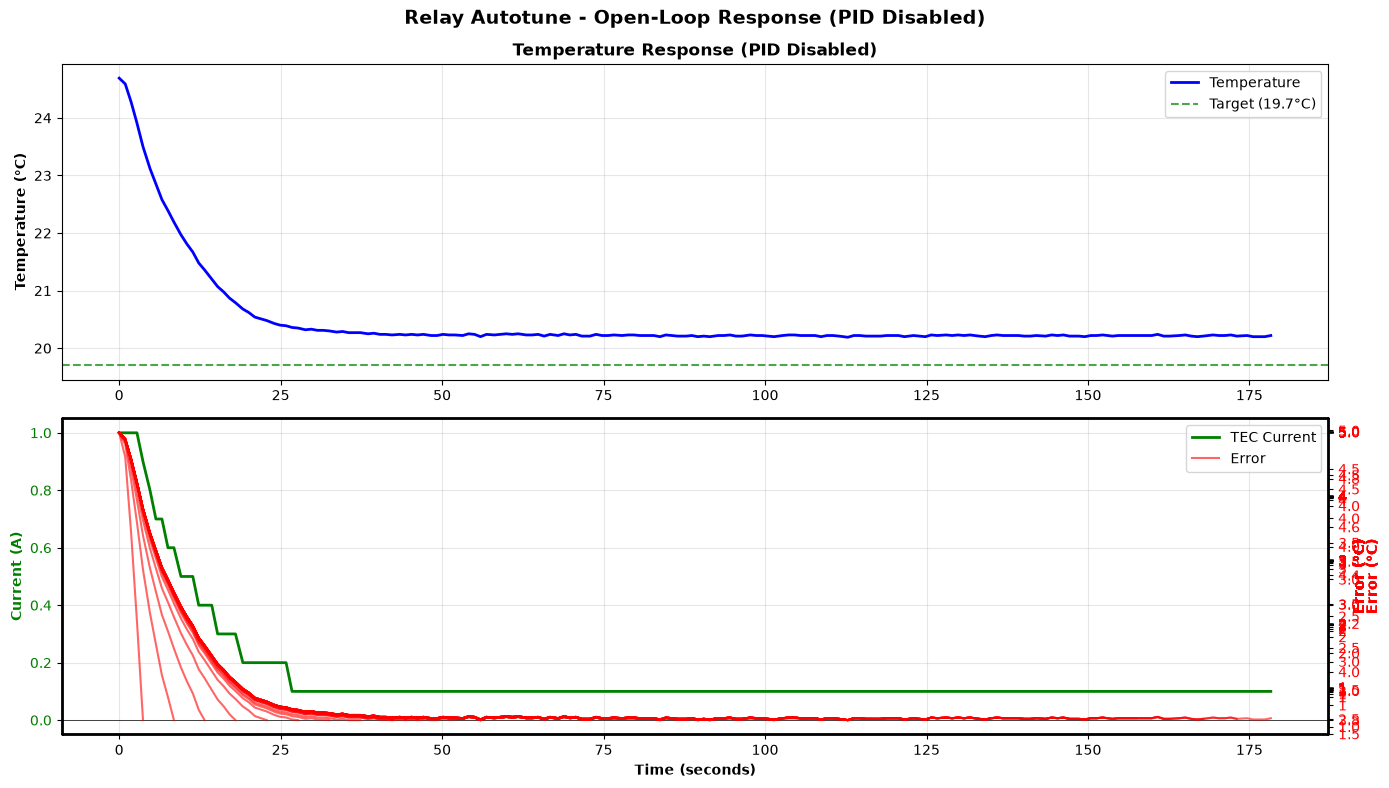


--- Cycles: 0/8 | Elapsed: 178.3s ---

   Time |     Temp |     Error |     Δ | Current | Status
----------------------------------------------------------------------
 179.8s |    20.23 |    +0.530 |  0.53 |  +0.100 |        
----------------------------------------------------------------------

ANALYSIS: 0 zero crossings (0 cycles)

⚠ Not enough oscillations. The system may be too slow without P/I control.
   Options:
   1. Increase STEP_SIZE to 10°C or more
   2. Wait longer (increase TIMEOUT)
   3. Consider that open-loop response may be very damped

To restore PID: controller.set_pid(50, 50, 1)

Restoring original PID: P=50  I=50  D=1
✓ Original PID restored

✓ Ready to test new PID values - see register estimates above


In [6]:
print("\n" + "="*70)
print("RELAY AUTOTUNE WITH LIVE PLOTTING")
print("(PID DISABLED - Open-Loop Oscillations Only)")
print("="*70 + "\n")

import math
import statistics
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Configuration
STEP_SIZE = -5.0          # 5°C step (must be large to see oscillations without P/I)
CYCLES_TARGET = 8       # Complete oscillation cycles
SAMPLE_INTERVAL = 0.5    # Fast sampling
TIMEOUT = 180            # Increased to 5 min (oscillations slower without PID damping)
PLOT_UPDATE_INTERVAL = 5 # Redraw plot every N samples (saves CPU)

print(f"Configuration:")
print(f"  Step size: {STEP_SIZE}°C")
print(f"  Target cycles: {CYCLES_TARGET}")
print(f"  Sampling: every {SAMPLE_INTERVAL}s")
print(f"  Live plot: updates every {PLOT_UPDATE_INTERVAL} samples\n")

# ============================================================================
# Setup - Disable Existing PID
# ============================================================================
print("="*70)
print("STEP 1: Setup - Disable Existing PID")
print("="*70)

tec_stop()
time.sleep(3)

# Save current PID before zeroing
orig_p, orig_i, orig_d = controller.get_pid()
print(f"\nOriginal PID: P={orig_p}  I={orig_i}  D={orig_d}")

# Disable P and I, keep D=1 (firmware requirement: D cannot be 0)
print(f"Disabling PID control (P=20, I=0, D=1)...")
controller.set_pid(20, 0, 1)
time.sleep(1)

p_check, i_check, d_check = controller.get_pid()
print(f"PID after disable: P={p_check}  I={i_check}  D={d_check}")
print(f"\n⚠ WARNING: With P=20  and I=0, control is disabled.")
print(f"   The system will respond ONLY to thermal dynamics (open-loop).")
print(f"   Oscillations will be much slower and require patience.\n")

t_baseline = controller.get_tec_temperature()
t_target = round(t_baseline + STEP_SIZE, 1)

print(f"Baseline temp: {t_baseline:.2f}°C")
print(f"Target step: {t_target:.2f}°C (↑{STEP_SIZE}°C)\n")

# ============================================================================
# Run with live plotting
# ============================================================================
print("="*70)
print("STEP 2: Start TEC - watch live plot (may take several minutes)")
print("="*70 + "\n")

# Setup matplotlib for interactive mode
plt.ioff()  # Turn off automatic redraw
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Relay Autotune - Open-Loop Response (PID Disabled)', fontsize=14, fontweight='bold')

if not tec_start(t_target):
    print("⚠ TEC failed to start")
else:
    readings = []
    zero_crossings = []
    peaks = []
    
    last_error = None
    start_time = time.time()
    sample_count = 0

    print(f"{'Time':>7} | {'Temp':>8} | {'Error':>9} | {'Δ':>5} | Current | Status")
    print("-" * 70)

    while time.time() - start_time < TIMEOUT:
        elapsed = time.time() - start_time
        temp = controller.get_tec_temperature()
        current = controller.get_tec_current()
        error = temp - t_target

        readings.append((elapsed, temp, current, error))

        # Detect zero crossing (error changes sign)
        sign_changed = False
        if last_error is not None:
            if (last_error < 0 <= error) or (last_error > 0 >= error):
                zero_crossings.append(elapsed)
                peaks.append(abs(error))
                sign_changed = True

        last_error = error
        n_cycles = len(zero_crossings) // 2
        status = "→ CROSS" if sign_changed else "       "

        print(f"{elapsed:>6.1f}s | {temp:>8.2f} | {error:>+9.3f} | {abs(error):>5.2f} | {current:>+7.3f} | {status}")

        # Update live plot every N samples
        sample_count += 1
        if sample_count % PLOT_UPDATE_INTERVAL == 0:
            clear_output(wait=True)
            
            # Extract data
            times = [r[0] for r in readings]
            temps = [r[1] for r in readings]
            currents = [r[2] for r in readings]
            errors = [r[3] for r in readings]

            # Plot 1: Temperature
            axes[0].clear()
            axes[0].plot(times, temps, 'b-', linewidth=2, label='Temperature')
            axes[0].axhline(y=t_target, color='g', linestyle='--', linewidth=1.5, 
                           alpha=0.7, label=f'Target ({t_target}°C)')
            if zero_crossings:
                zc_temps = [r[1] for r in readings if r[0] in zero_crossings]
                axes[0].scatter(zero_crossings, zc_temps, color='red', s=80, 
                              marker='x', linewidths=2, label='Zero Crossing', zorder=5)
            axes[0].set_ylabel('Temperature (°C)', fontweight='bold')
            axes[0].set_title('Temperature Response (PID Disabled)', fontweight='bold')
            axes[0].grid(True, alpha=0.3)
            axes[0].legend(loc='best')
            
            # Plot 2: Current & Error
            ax1 = axes[1]
            ax1.clear()
            ax1.plot(times, currents, 'g-', linewidth=2, label='TEC Current')
            ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
            ax1.set_ylabel('Current (A)', color='g', fontweight='bold')
            ax1.tick_params(axis='y', labelcolor='g')
            ax1.grid(True, alpha=0.3)
            ax1.set_xlabel('Time (seconds)', fontweight='bold')
            
            # Twin axis for error
            ax2 = ax1.twinx()
            ax2.plot(times, errors, 'r-', linewidth=1.5, alpha=0.6, label='Error')
            ax2.set_ylabel('Error (°C)', color='r', fontweight='bold')
            ax2.tick_params(axis='y', labelcolor='r')
            
            # Add legend
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

            plt.tight_layout()
            display(fig)
            
            # Print progress
            print(f"\n--- Cycles: {n_cycles}/{CYCLES_TARGET} | Elapsed: {elapsed:.1f}s ---\n")
            print(f"{'Time':>7} | {'Temp':>8} | {'Error':>9} | {'Δ':>5} | Current | Status")
            print("-" * 70)

        # Stop when we have enough cycles
        if n_cycles >= CYCLES_TARGET:
            break

        time.sleep(SAMPLE_INTERVAL)

    plt.close(fig)

    # ============================================================================
    # Analysis
    # ============================================================================
    print("-" * 70)
    print(f"\n{'='*70}")
    print(f"ANALYSIS: {len(zero_crossings)} zero crossings ({len(zero_crossings)//2} cycles)")
    print(f"{'='*70}\n")

    if len(zero_crossings) < 4:
        print("⚠ Not enough oscillations. The system may be too slow without P/I control.")
        print("   Options:")
        print("   1. Increase STEP_SIZE to 10°C or more")
        print("   2. Wait longer (increase TIMEOUT)")
        print("   3. Consider that open-loop response may be very damped\n")
        print(f"To restore PID: controller.set_pid({orig_p}, {orig_i}, {orig_d})")
    else:
        # Calculate metrics from STABLE oscillations (skip first 2 crossings)
        stable_crossings = zero_crossings[2:]
        periods = []
        for i in range(0, len(stable_crossings) - 1, 2):
            period = stable_crossings[i+1] - stable_crossings[i]
            periods.append(period)

        Tu = 2.0 * statistics.mean(periods)
        a = statistics.mean(peaks[2:])
        d = controller.get_tec_current_limit()

        print(f"Oscillation Metrics (OPEN-LOOP, PID Disabled):")
        print(f"  Ultimate period Tu = {Tu:.3f}s  (frequency: {1/Tu:.2f} Hz)")
        print(f"  Amplitude a = ±{a:.3f}°C")
        print(f"  Current limit d = {d:.2f}A")

        # Ziegler-Nichols: these values are for the OPEN-LOOP plant
        Ku = (4.0 * d) / (math.pi * (2.0 * a))

        Kp_zn = 0.6 * Ku
        Ki_zn = 1.2 * Ku / Tu
        Kd_zn = 0.075 * Ku * Tu

        print(f"\nZiegler-Nichols Calculated (Open-Loop Plant):")
        print(f"  Ku (ultimate gain) = {Ku:.3f}")
        print(f"  Kp = {Kp_zn:.1f}")
        print(f"  Ki = {Ki_zn:.1f}")
        print(f"  Kd = {Kd_zn:.1f}")

        # Device register scaling
        P_reg = int(Kp_zn * 10)
        I_reg = int(Ki_zn * 100)
        D_reg = int(Kd_zn * 10)

        print(f"\nEstimated Device Registers:")
        print(f"  P ≈ {P_reg}")
        print(f"  I ≈ {I_reg}")
        print(f"  D ≈ {D_reg}")
        print(f"\n✓ These are tuned for the OPEN-LOOP plant response.")
        print(f"  Fine-tune empirically in the next step.")

        # Final summary plot
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        fig.suptitle('Relay Autotune - Final Results (Open-Loop Plant)', fontsize=14, fontweight='bold')

        times = [r[0] for r in readings]
        temps = [r[1] for r in readings]
        currents = [r[2] for r in readings]
        errors = [r[3] for r in readings]

        # Temperature plot
        axes[0].plot(times, temps, 'b-', linewidth=2.5, label='Temperature')
        axes[0].axhline(y=t_target, color='g', linestyle='--', linewidth=2, alpha=0.7, label=f'Target')
        if zero_crossings:
            zc_temps = [r[1] for r in readings if r[0] in zero_crossings]
            axes[0].scatter(zero_crossings, zc_temps, color='red', s=100, marker='x', 
                          linewidths=2.5, label='Zero Crossing', zorder=5)
        axes[0].set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
        axes[0].set_title(f'Temperature Response - Open-Loop (Tu={Tu:.2f}s, a=±{a:.2f}°C)', fontsize=12, fontweight='bold')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc='best', fontsize=10)

        # Current & Error plot
        axes[1].plot(times, currents, 'g-', linewidth=2.5, label='TEC Current')
        axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        axes[1].fill_between(times, 0, currents, alpha=0.2, color='g')
        axes[1].set_ylabel('Current (A)', color='g', fontsize=11, fontweight='bold')
        axes[1].tick_params(axis='y', labelcolor='g')
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')

        # Twin axis for error
        ax2 = axes[1].twinx()
        ax2.plot(times, errors, 'r-', linewidth=2, alpha=0.7, label='Error')
        ax2.set_ylabel('Error (°C)', color='r', fontsize=11, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='r')

        lines1, labels1 = axes[1].get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        axes[1].legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

        plt.tight_layout()
        plt.show()

tec_stop()
time.sleep(3)

# Restore original PID
print(f"\n{'='*70}")
print(f"Restoring original PID: P={orig_p}  I={orig_i}  D={orig_d}")
controller.set_pid(orig_p, orig_i, orig_d)
print(f"✓ Original PID restored\n")
print("✓ Ready to test new PID values - see register estimates above")

In [ ]:
# Get default PID
P, I, D = controller.get_pid()
print(f"Current PID: P={P}  I={I}  D={D}\n")


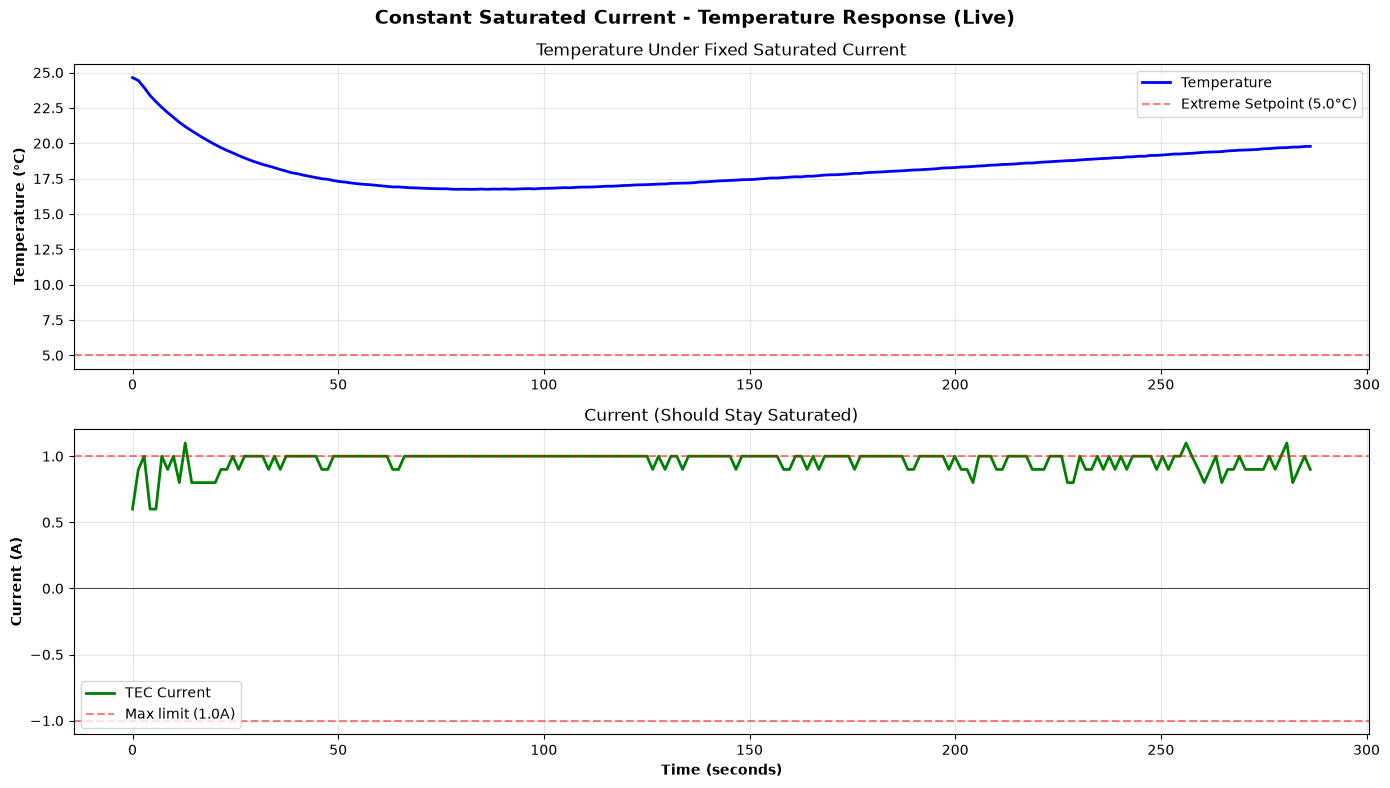


--- Elapsed: 286s / 300s ---

  Time |  Temp (°C) | Current (A) | Status
------------------------------------------------------------
  288s |      19.83 |     +0.700 | ---
  289s |      19.86 |     +0.900 | ---
  291s |      19.89 |     +1.000 | SAT
  292s |      19.89 |     +0.900 | ---
  294s |      19.91 |     +1.000 | SAT
  295s |      19.94 |     +1.000 | SAT
  296s |      19.96 |     +0.900 | ---
  298s |      20.00 |     +0.800 | ---
  299s |      20.01 |     +0.900 | ---
------------------------------------------------------------

ANALYSIS: Temperature Oscillations Under Constant Saturated Current

Temperature Statistics:
  Min: 16.74°C
  Max: 24.64°C
  Range: 7.90°C
  Total rise/fall: 4.63°C

Current Statistics:
  Average: +0.957A
  Max limit: 1.00A
  Saturated: YES

Oscillations Detected: 14
  Peaks: 7
  Valleys: 7


TypeError: list indices must be integers or slices, not float

In [9]:
print("\n" + "="*70)
print("CONSTANT CURRENT TEST - Force Saturation with Extreme Setpoint")
print("="*70 + "\n")

import matplotlib.pyplot as plt
from IPython.display import clear_output

# ============================================================================
# Setup
# ============================================================================
print("STEP 1: Setup")
print("-" * 70)

tec_stop()
time.sleep(3)

# Save original PID
orig_p, orig_i, orig_d = controller.get_pid()
print(f"Original PID: P={orig_p}  I={orig_i}  D={orig_d}")

# Set PID for saturation: moderate P, zero I/D
# Large error × P = saturated current (max limit)
P_SAT = 100        # Moderate P to allow saturation
controller.set_pid(P_SAT, 0, 1)
print(f"Saturation PID: P={P_SAT}  I=0  D=1")

t_baseline = controller.get_tec_temperature()
print(f"Baseline temperature: {t_baseline:.2f}°C\n")

# ============================================================================
# Apply extreme setpoint to force current saturation
# ============================================================================
print("STEP 2: Apply Extreme Setpoint (Force Current Saturation)")
print("-" * 70)

# For HEATING (positive current): set target very HIGH
# EXTREME_SETPOINT = 70.0  # Way above room temp

# For COOLING (negative current): uncomment below
EXTREME_SETPOINT = 5.0   # Way below room temp

print(f"Extreme setpoint: {EXTREME_SETPOINT}°C")
print(f"This will force current to saturate at hardware limit")
print(f"Measuring temperature response for 5 minutes...\n")

max_current_limit = controller.get_tec_current_limit()
print(f"Max current available: ±{max_current_limit:.2f}A\n")

# Setup live plotting
plt.ioff()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Constant Saturated Current - Temperature Response (Live)', fontsize=14, fontweight='bold')

print(f"{'Time':>6} | {'Temp (°C)':>10} | {'Current (A)':>10} | Status")
print("-" * 60)

# Start TEC with extreme setpoint
if not tec_start(EXTREME_SETPOINT):
    print("⚠ TEC failed to start")
else:
    readings = []
    start_time = time.time()
    sample_count = 0
    TOTAL_DURATION = 300  # 5 minutes
    SAMPLE_INTERVAL = 1   # 1 second between samples
    PLOT_UPDATE_INTERVAL = 10  # Update plot every 10 samples
    
    while time.time() - start_time < TOTAL_DURATION:
        elapsed = time.time() - start_time
        temp = controller.get_tec_temperature()
        current = controller.get_tec_current()
        
        readings.append((elapsed, temp, current))
        
        # Check if current is saturated
        is_saturated = abs(current) > max_current_limit * 0.95
        status = "SAT" if is_saturated else "---"
        
        print(f"{elapsed:>5.0f}s | {temp:>10.2f} | {current:>+10.3f} | {status}")
        
        # Update live plot every N samples
        sample_count += 1
        if sample_count % PLOT_UPDATE_INTERVAL == 0:
            clear_output(wait=True)
            
            times = [r[0] for r in readings]
            temps = [r[1] for r in readings]
            currents = [r[2] for r in readings]
            
            # Temperature plot
            axes[0].clear()
            axes[0].plot(times, temps, 'b-', linewidth=2, label='Temperature')
            axes[0].axhline(y=EXTREME_SETPOINT, color='r', linestyle='--', alpha=0.5, label=f'Extreme Setpoint ({EXTREME_SETPOINT}°C)')
            axes[0].set_ylabel('Temperature (°C)', fontweight='bold')
            axes[0].set_title('Temperature Under Fixed Saturated Current')
            axes[0].grid(True, alpha=0.3)
            axes[0].legend(loc='best')
            
            # Current plot
            axes[1].clear()
            axes[1].plot(times, currents, 'g-', linewidth=2, label='TEC Current')
            axes[1].axhline(y=max_current_limit, color='r', linestyle='--', alpha=0.5, label=f'Max limit ({max_current_limit:.1f}A)')
            axes[1].axhline(y=-max_current_limit, color='r', linestyle='--', alpha=0.5)
            axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
            axes[1].set_ylabel('Current (A)', fontweight='bold')
            axes[1].set_xlabel('Time (seconds)', fontweight='bold')
            axes[1].set_title('Current (Should Stay Saturated)')
            axes[1].grid(True, alpha=0.3)
            axes[1].legend(loc='best')
            
            plt.tight_layout()
            display(fig)
            
            # Print progress header
            print(f"\n--- Elapsed: {elapsed:.0f}s / {TOTAL_DURATION}s ---\n")
            print(f"{'Time':>6} | {'Temp (°C)':>10} | {'Current (A)':>10} | Status")
            print("-" * 60)
        
        time.sleep(SAMPLE_INTERVAL)
    
    plt.close(fig)
    print("-" * 60)
    
    # ============================================================================
    # Analysis: Look for temperature oscillations
    # ============================================================================
    print(f"\n{'='*70}")
    print("ANALYSIS: Temperature Oscillations Under Constant Saturated Current")
    print(f"{'='*70}\n")
    
    times = [r[0] for r in readings]
    temps = [r[1] for r in readings]
    currents = [r[2] for r in readings]
    
    # Calculate temperature statistics
    temp_min = min(temps)
    temp_max = max(temps)
    temp_range = temp_max - temp_min
    
    # Look for oscillations by detecting local maxima/minima
    oscillations = []
    for i in range(1, len(temps) - 1):
        if temps[i] > temps[i-1] and temps[i] > temps[i+1]:  # Local max
            oscillations.append(('peak', i, temps[i]))
        elif temps[i] < temps[i-1] and temps[i] < temps[i+1]:  # Local min
            oscillations.append(('valley', i, temps[i]))
    
    print(f"Temperature Statistics:")
    print(f"  Min: {temp_min:.2f}°C")
    print(f"  Max: {temp_max:.2f}°C")
    print(f"  Range: {temp_range:.2f}°C")
    print(f"  Total rise/fall: {abs(temps[-1] - temps[0]):.2f}°C")
    
    # Check current saturation
    avg_current = sum(currents) / len(currents)
    print(f"\nCurrent Statistics:")
    print(f"  Average: {avg_current:+.3f}A")
    print(f"  Max limit: {max_current_limit:.2f}A")
    print(f"  Saturated: {'YES' if abs(avg_current) > max_current_limit * 0.9 else 'NO'}")
    
    print(f"\nOscillations Detected: {len(oscillations)}")
    if len(oscillations) > 0:
        print(f"  Peaks: {sum(1 for o in oscillations if o[0]=='peak')}")
        print(f"  Valleys: {sum(1 for o in oscillations if o[0]=='valley')}")
        
        # Calculate period if there are oscillations
        peak_times = [times[o[2]] for o in oscillations if o[0]=='peak']
        if len(peak_times) >= 2:
            periods = [peak_times[i+1] - peak_times[i] for i in range(len(peak_times)-1)]
            avg_period = sum(periods) / len(periods)
            print(f"  Average period: {avg_period:.1f}s")
    else:
        print(f"  ⚠ No oscillations detected - system is heavily damped")
        print(f"  This means the thermal system is overdamped and won't ring")
    
    # Final summary plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Constant Saturated Current - Final Results', fontsize=14, fontweight='bold')
    
    # Temperature plot
    axes[0].plot(times, temps, 'b-', linewidth=2.5, label='Temperature')
    axes[0].axhline(y=EXTREME_SETPOINT, color='r', linestyle='--', alpha=0.5, linewidth=2, label=f'Extreme Setpoint ({EXTREME_SETPOINT}°C)')
    axes[0].set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
    axes[0].set_title('Temperature Response to Saturated Current')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='best', fontsize=10)
    
    # Current plot
    axes[1].plot(times, currents, 'g-', linewidth=2.5, label='TEC Current')
    axes[1].axhline(y=max_current_limit, color='r', linestyle='--', alpha=0.5, linewidth=2, label=f'Saturation limit')
    axes[1].axhline(y=-max_current_limit, color='r', linestyle='--', alpha=0.5, linewidth=2)
    axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[1].fill_between(times, 0, currents, alpha=0.2, color='g')
    axes[1].set_ylabel('Current (A)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    axes[1].set_title('Current Saturation Profile')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.show()

tec_stop()
time.sleep(3)

# Restore original PID
print(f"\nRestoring original PID: P={orig_p}  I={orig_i}  D={orig_d}")
controller.set_pid(orig_p, orig_i, orig_d)
print("✓ Test complete")

In [10]:
print("\n" + "="*70)
print("CORRECTED OSCILLATION ANALYSIS")
print("="*70 + "\n")

# Assuming you have: times, temps, currents from the previous test

times = [r[0] for r in readings]
temps = [r[1] for r in readings]
currents = [r[2] for r in readings]

# Re-detect oscillations correctly
oscillations = []
for i in range(1, len(temps) - 1):
    if temps[i] > temps[i-1] and temps[i] > temps[i+1]:  # Local max
        oscillations.append(('peak', i, temps[i]))
    elif temps[i] < temps[i-1] and temps[i] < temps[i+1]:  # Local min
        oscillations.append(('valley', i, temps[i]))

# Extract peak times correctly
peak_indices = [o[1] for o in oscillations if o[0]=='peak']  # Use o[1], not o[2]!
peak_times = [times[idx] for idx in peak_indices]

print(f"Oscillations Detected: {len(oscillations)} total")
print(f"  Peaks: {len([o for o in oscillations if o[0]=='peak'])}")
print(f"  Valleys: {len([o for o in oscillations if o[0]=='valley'])}\n")

# Calculate period from peak-to-peak timing
if len(peak_times) >= 2:
    periods = [peak_times[i+1] - peak_times[i] for i in range(len(peak_times)-1)]
    Tu = 2.0 * statistics.mean(periods)
    print(f"Peak-to-peak times: {periods}")
    print(f"Average period (half-cycle): {statistics.mean(periods):.2f}s")
    print(f"Ultimate period Tu: {Tu:.2f}s")
    print(f"Frequency: {1/Tu:.3f} Hz\n")
    
    # Amplitude (use stable oscillations, skip first 2)
    if len([o for o in oscillations if o[0]=='peak']) > 2:
        peak_values = [o[2] for o in oscillations if o[0]=='peak'][2:]
        valley_values = [o[2] for o in oscillations if o[0]=='valley'][2:]
        
        if peak_values and valley_values:
            avg_peak = statistics.mean(peak_values)
            avg_valley = statistics.mean(valley_values)
            a = (avg_peak - avg_valley) / 2.0
            
            print(f"Stable peak temperatures: {peak_values}")
            print(f"Stable valley temperatures: {valley_values}")
            print(f"Average peak: {avg_peak:.2f}°C")
            print(f"Average valley: {avg_valley:.2f}°C")
            print(f"Amplitude a = ±{a:.2f}°C\n")
            
            # Ziegler-Nichols calculation
            d = controller.get_tec_current_limit()
            Ku = (4.0 * d) / (math.pi * (2.0 * a))
            
            Kp_zn = 0.6 * Ku
            Ki_zn = 1.2 * Ku / Tu
            Kd_zn = 0.075 * Ku * Tu
            
            print("="*70)
            print("ZIEGLER-NICHOLS TUNING PARAMETERS")
            print("="*70)
            print(f"Ultimate gain Ku = {Ku:.3f}")
            print(f"  Kp (proportional) = {Kp_zn:.2f}")
            print(f"  Ki (integral)     = {Ki_zn:.2f}")
            print(f"  Kd (derivative)   = {Kd_zn:.2f}\n")
            
            # Device register scaling
            P_reg = int(Kp_zn * 10)
            I_reg = int(Ki_zn * 100)
            D_reg = int(Kd_zn * 10)
            
            print("DEVICE REGISTER VALUES:")
            print(f"  P ≈ {P_reg}")
            print(f"  I ≈ {I_reg}")
            print(f"  D ≈ {D_reg}\n")
            
            print("Next: Test these values with the PID adjustment cell")
            print(f"      NEW_P = {P_reg}")
            print(f"      NEW_I = {I_reg}")
            print(f"      NEW_D = {D_reg}")



CORRECTED OSCILLATION ANALYSIS

Oscillations Detected: 14 total
  Peaks: 7
  Valleys: 7

Peak-to-peak times: [4.2507734298706055, 2.9854540824890137, 2.847290277481079, 5.6848249435424805, 8.696195125579834, 56.19697332382202]
Average period (half-cycle): 13.44s
Ultimate period Tu: 26.89s
Frequency: 0.037 Hz

Stable peak temperatures: [16.76, 16.77, 16.79, 16.86, 17.63]
Stable valley temperatures: [16.75, 16.75, 16.77, 16.85, 17.62]
Average peak: 16.96°C
Average valley: 16.95°C
Amplitude a = ±0.01°C

ZIEGLER-NICHOLS TUNING PARAMETERS
Ultimate gain Ku = 90.946
  Kp (proportional) = 54.57
  Ki (integral)     = 4.06
  Kd (derivative)   = 183.40

DEVICE REGISTER VALUES:
  P ≈ 545
  I ≈ 405
  D ≈ 1833

Next: Test these values with the PID adjustment cell
      NEW_P = 545
      NEW_I = 405
      NEW_D = 1833


In [ ]:
# Final summary plot
    # Final summary plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Constant Saturated Current - Final Results', fontsize=14, fontweight='bold')

    # Temperature plot
    axes[0].plot(times, temps, 'b-', linewidth=2.5, label='Temperature')
    axes[0].axhline(y=EXTREME_SETPOINT, color='r', linestyle='--', alpha=0.5, linewidth=2, label=f'Extreme Setpoint ({EXTREME_SETPOINT}°C)')
    axes[0].set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
    axes[0].set_title('Temperature Response to Saturated Current')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='best', fontsize=10)

    # Current plot
    axes[1].plot(times, currents, 'g-', linewidth=2.5, label='TEC Current')
    axes[1].axhline(y=max_current_limit, color='r', linestyle='--', alpha=0.5, linewidth=2, label=f'Saturation limit')
    axes[1].axhline(y=-max_current_limit, color='r', linestyle='--', alpha=0.5, linewidth=2)
    axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[1].fill_between(times, 0, currents, alpha=0.2, color='g')
    axes[1].set_ylabel('Current (A)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    axes[1].set_title('Current Saturation Profile')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='best', fontsize=10)

    plt.tight_layout()
    plt.show()

    tec_stop()
    time.sleep(3)
    fig.suptitle('Constant Saturated Current - Final Results', fontsize=14, fontweight='bold')
    
    # Temperature plot
    axes[0].plot(times, temps, 'b-', linewidth=2.5, label='Temperature')
    axes[0].axhline(y=EXTREME_SETPOINT, color='r', linestyle='--', alpha=0.5, linewidth=2, label=f'Extreme Setpoint ({EXTREME_SETPOINT}°C)')
    axes[0].set_ylabel('Temperature (°C)', fontsize=11, fontweight='bold')
    axes[0].set_title('Temperature Response to Saturated Current')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='best', fontsize=10)
    
    # Current plot
    axes[1].plot(times, currents, 'g-', linewidth=2.5, label='TEC Current')
    axes[1].axhline(y=max_current_limit, color='r', linestyle='--', alpha=0.5, linewidth=2, label=f'Saturation limit')
    axes[1].axhline(y=-max_current_limit, color='r', linestyle='--', alpha=0.5, linewidth=2)
    axes[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[1].fill_between(times, 0, currents, alpha=0.2, color='g')
    axes[1].set_ylabel('Current (A)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')
    axes[1].set_title('Current Saturation Profile')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    plt.show()

tec_stop()
time.sleep(3)


In [ ]:
print("\n" + "="*70)
print("TESTING CALCULATED PID COEFFICIENTS")
print("="*70 + "\n")

# Your calculated values
Kp_calc = 1.45
Ki_calc = 1.5
Kd_calc = 1.0

# Convert to device register values (depends on your device scaling)
# These might need adjustment based on your Maiman device calibration
# Start with 1:1 mapping or 100x if device expects integer registers
# P_test = int(Kp_calc * 100)  # e.g., 145
# I_test = int(Ki_calc * 100)  # e.g., 50
# D_test = int(Kd_calc * 100)  # e.g., 140
P_test = 153
I_test =315
D_test = 185

print(f"Testing PID registers: P={P_test} I={I_test} D={D_test}\n")

# Stop TEC before changing PID
tec_stop()
time.sleep(3)

# Set the PID values
try:
    controller.set_pid(P_test, I_test, D_test)
    print("✓ PID values set")
except Exception as e:
    print(f"Error setting PID: {e}")

# Get current temperature
t_now = controller.get_tec_temperature()
target = round(t_now - 1.0, 2)  # Set target 1°C below current

print(f"\nStep response test: {t_now:.2f}°C → {target:.2f}°C\n")

# Start TEC with the new PID values
if tec_start(target):
    print(f"{'Time':>6} | {'Temp':>8} | {'Error':>8} | {'I(A)':>8} | Status")
    print("-" * 55)
    
    for i in range(30):
        elapsed = i * 2
        temp = controller.get_tec_temperature()
        current = controller.get_tec_current()
        error = temp - target
        
        status = "stable" if abs(error) <= 0.1 else "settling"
        print(f"{elapsed:>5}s | {temp:>8.2f} | {error:>+8.2f} | {current:>+8.3f} | {status}")
        
        time.sleep(2)
    
    t_final = controller.get_tec_temperature()
    print("-" * 55)
    print(f"\nFinal error: {t_final - target:+.2f}°C")
    print(f"Goal: < ±0.1°C")
    
    if abs(t_final - target) <= 0.1:
        print("✓ EXCELLENT - PID coefficients working perfectly!")
    elif abs(t_final - target) <= 0.5:
        print("✓ GOOD - Minor tuning needed")
    else:
        print("⚠ NEEDS TUNING - See adjustment options below")

tec_stop()


In [ ]:
print("Shutting down...")
try:
    controller.set_driver_off()
    controller.set_tec_off()
except Exception:
    pass
try:
    if controller.temperature_thread.is_alive():
        controller.end_threads = True
        controller.temperature_thread.join(timeout=5)
    if controller.dev.is_open:
        controller.dev.close()
    print("Port closed cleanly.")
except Exception as e:
    print(f"Cleanup warning: {e}")
print("Done")